# Analysing simulation results (12 Aug 2026)

## Setup

In [ ]:
# ── Environment switch: Colab or laptop ─────────────────────────────────────
# Mirrors 2a–2d so this notebook runs in the same two places they do. Without
# it, every path below ("results/...", "data/...") is resolved against whatever
# directory the kernel happened to start in — which is what a
# FileNotFoundError on results/option1_literature_summary.csv actually means:
# not a missing file, a wrong working directory.
import os, sys, subprocess, shutil
from pathlib import Path

RUNNING_LOCALLY = False   # False → Colab: force-fresh clone, then mount Drive
RUN_TAG         = 'full'  # which tier of the study to read: 'full' or 'smoke'
INSTALL_LATEX   = False   # True → apt-get TeX so text.usetex figures render (~3 min)

# Uses subprocess/os.chdir rather than !/% magics so the RUNNING_LOCALLY guard
# actually holds — a line magic fires regardless of the surrounding `if`
# (NOTEBOOK_WRITING_SKILL §5–6).
if not RUNNING_LOCALLY:
    COLAB_BASE = Path('/content')
    os.chdir(COLAB_BASE)
    repo_dir = COLAB_BASE / 'e_network_inequality'
    if repo_dir.exists():
        shutil.rmtree(repo_dir)
    subprocess.run(['git', 'clone', '-b', 'main',
                    'https://github.com/IgnacioOQ/e_network_inequality'], check=True)
    os.chdir(repo_dir)
    subprocess.run(['pip', 'install', '-q', 'python-dotenv'], check=True)
    if INSTALL_LATEX:
        # The plotting cells set text.usetex=True. Colab has no TeX, and
        # matplotlib fails at RENDER time rather than at import, so the error
        # surfaces from inside seaborn and reads like a plotting bug.
        subprocess.run(['apt-get', '-qq', 'install', '-y', 'texlive-latex-extra',
                        'texlive-fonts-recommended', 'dvipng', 'cm-super'], check=True)
else:
    PROJECT_ROOT = Path.cwd()
    while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'model').is_dir():
        PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

# Every figure cell below reads this. Set once, here, so a runtime without TeX
# degrades to mathtext instead of raising three cells later.
USETEX = RUNNING_LOCALLY or INSTALL_LATEX

print("Working dir:", REPO_ROOT)
print("text.usetex:", USETEX)

In [1]:
import os

import pandas as pd
import numpy as np
import networkx as nx
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore
import scipy.stats as stats

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from pathlib import Path
from dotenv import load_dotenv

load_dotenv()  # Loads from .env in project root
paper_fig_dir = os.getenv('PAPER_FIG_DIR')

### Where the summary CSVs come from

`2a`/`2b`/`2c` bank their shards on Drive and `2d` aggregates them into `<option>_summary.csv` under `notebook3_inputs/<RUN_TAG>/`. Two of those files (`option1`, `option3`) are also committed to the repo's `results/`; a freshly aggregated one exists **only on Drive** until someone copies it across.

The loader checks Drive first, then the repo, and prints which it used.

In [ ]:
# The same environment split as 2a–2d — one path constant, defined once.
if RUNNING_LOCALLY:
    STUDY_ROOT = Path('results/equality_study')
else:
    from google.colab import drive
    drive.mount('/content/drive')
    STUDY_ROOT = Path('/content/drive/My Drive/Colab Projects/Data Driven ABMs/'
                      'Data Sets/equality_study')

# Two places a summary can be, checked in this order:
#   1. Drive, where 2d just wrote it — the only place a newly aggregated option
#      exists, and always the freshest copy of one that is still growing
#   2. the repo's results/ — where option1 and option3 are committed
# Second is a fallback, not a duplicate: without it, option1/option3 would stop
# loading on any runtime where Drive is not mounted.
SUMMARY_SEARCH_PATH = [
    STUDY_ROOT / 'notebook3_inputs' / RUN_TAG,
    REPO_ROOT / 'results',
]

# Figures: the Colab clone is discarded with the runtime, so writing them into
# ./results/ there loses them silently. Drive persists; the repo does locally.
FIGURE_DIR = REPO_ROOT / 'results' if RUNNING_LOCALLY else STUDY_ROOT / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Looking for summaries in:")
for directory in SUMMARY_SEARCH_PATH:
    print(f"  {'OK     ' if directory.is_dir() else 'absent '} {directory}")
print("Figures ->", FIGURE_DIR)


def load_summary(slug):
    """Load one option's variant summary from wherever it actually is.

    Also reports completeness when 2d wrote it. A partial arm produces a
    perfectly ordinary regression — nothing downstream would mention that a
    network is at 68% of its target — so the one chance to notice is at load.
    """
    name = f'{slug}_summary.csv'
    for directory in SUMMARY_SEARCH_PATH:
        candidate = directory / name
        if not candidate.exists():
            continue
        df = pd.read_csv(candidate)
        print(f"Loaded {name}: {len(df):,} rows from {directory}")
        print(df['network'].value_counts().to_string())

        completeness = directory / 'completeness.csv'
        if completeness.exists():
            report = pd.read_csv(completeness)
            partial = report[(report['option'] == slug) & (report['complete'] == False)]  # noqa: E712
            for row in partial.itertuples():
                print(f"  !!! PARTIAL — {row.network}/{row.method}: "
                      f"{row.variants_summarised:,} of {row.variants_target:,} ({row.pct}%)")
        return df

    tried = '\n'.join(f'    {d / name}' for d in SUMMARY_SEARCH_PATH)
    raise FileNotFoundError(
        f"{name} is in none of the searched locations:\n{tried}\n"
        "  Run 2d. GColab Simulations Equality - Aggregation.ipynb to produce it, "
        "or check RUN_TAG.")

In [2]:
rename_dict = {
    'uncertainty': 'Problem Easiness',
    'n_experiments': 'Number of Experiments',
    'share_of_correct_agents_at_convergence':'Share of correct agents',
    'mean_share_of_correct_agents_at_convergence':'Share of correct agents (mean)',
    'degree_average': 'Mean Degree',
    'average_degree': 'Average Degree',
    'clustering_average':'Clustering Coeff.',
    'approx_average_clustering_coefficient':'Clustering Coeff.',
    'degree_gini':'Degree Gini Coeff.',
    'degree_gini_coefficient': 'Degree Gini Coeff.',
}

In [3]:
def VIF_interpretation(score: float) -> str:
    if score >= 5:
        return "high multicollinearity"
    elif score > 1.5:
        return "acceptable multicollinearity"
    elif score > 1:
        return "minimal multicollinearity"
    elif score == 1:
        return "no multicollinearity"
    else:
        return "something went wrong"


def compute_vif(
    df: pd.DataFrame,
    columns_corr: list[str] = [
        "degree_average", "degree_gini", "clustering_average"
    ],
    rename_dict:dict[str,str] = rename_dict
) -> pd.DataFrame:
    X = df[columns_corr].copy()
    X_const = X
    X_const = sm.add_constant(X)

    vif_data = pd.DataFrame(
        {
            "variable": X_const.columns,
            "VIF": [
                variance_inflation_factor(X_const.values, i)
                for i in range(X_const.shape[1])
            ],
            "VIF interpretation": [
                VIF_interpretation(variance_inflation_factor(X_const.values, i))
                for i in range(X_const.shape[1])
            ],
        }
    )
    vif_df = pd.DataFrame(
        vif_data, 
        columns=["variable", "VIF", "VIF interpretation"])
    vif_df = vif_df[vif_df["variable"].isin(columns_corr)]
    vif_df = vif_df.set_index("variable")
    return vif_df.rename(rename_dict)

def pearson_interpretation(
      score: float
) -> str:
    score_abs = abs(score)
    if score_abs <= 0.1:
        return "insignificant"
    elif score_abs <= 0.3:
        return "weak"
    elif score_abs <= 0.5:
        return "medium"
    elif score_abs <= 1:
        return "strong"
    else:
        return "error"

def compute_correlations(
    df: pd.DataFrame,
    columns_corr=["degree_average", "degree_gini", "clustering_average"],
    rename_dict: dict[str,str]=rename_dict,
) -> pd.DataFrame:
    df_corr = df[columns_corr].corr(method="pearson")
    df_corr_interpretation = df_corr.map(pearson_interpretation)

    mask = np.triu(np.ones(df_corr.shape, dtype=bool), k=1)

    result = (
        df_corr.where(mask)
        .stack()
        .rename("correlation")
        .to_frame()
    )
    result["interpretation"] = df_corr_interpretation.where(mask).stack()
    result.index.names = ["variable 1", "variable 2"]
    result = result.sort_values("correlation", key=abs, ascending=False)
    return result.dropna(how="all").rename(rename_dict)


In [4]:
def linear_regression(
        results_df: pd.DataFrame,
        predictors: list[str]=[
            "degree_gini_coefficient",
            "approx_average_clustering_coefficient",
        ],
        dependent_variable: str="mean_share_of_correct_agents_at_convergence",
        print_results: bool = True,
        print_full_summary: bool = True,
        return_latex: bool = False,
        latex_caption: str | None = None,
        latex_label: str = "tab:regression_results",
        latex_decimals: int = 3,
        return_stats: bool = False,
    ):
    # Get data
    X = results_df[predictors]
    y = results_df[[dependent_variable]].rename(columns=rename_dict)

    network = results_df["network"].iloc[0]

    # Add constant and fit model
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()

    # Compute descriptive statistics
    stats = (X.select_dtypes(include='number')
                .agg(['mean', 'std', 'min', 'max'])     # sample std (ddof=1)
                .T
                .rename(columns={'mean':'Mean', 'std':'Std', 'min': 'Min', 'max': 'Max'}))


    # p-values
    p_values = model.pvalues[1:]

    # Effect size (Cohen's f^2)
    # Cohen’s rules of thumb: 0.02 (small), 0.15 (medium), 0.35 (large).
    r2_full = model.rsquared
    f2_values = []
    for col in X.columns:
        X_reduced = X.drop(columns=[col])
        X_reduced = sm.add_constant(X_reduced)
        model_reduced = sm.OLS(y, X_reduced).fit()
        r2_reduced = model_reduced.rsquared
        f2 = (r2_full - r2_reduced) / (1 - r2_full)
        f2_values.append(f2)
    f_squared = pd.Series(f2_values, index=X.columns)

    f_squared = (model.tvalues[1:] ** 2) / model.df_resid

    def interpret_f2(f2):
        if f2 >= 0.35:
            return 'Large'
        elif f2 >= 0.15:
            return 'Medium'
        elif f2 >= 0.02:
            return 'Small'
        else:
            return 'Negligible'

    # Compute standardized coefficients
    # Standardize using zscore, and fit on standardized data
    X_std = zscore(X, ddof=1)
    y_std = zscore(y, ddof=1)
    model_std = sm.OLS(y_std, sm.add_constant(X_std)).fit()
    coef_normalized = model_std.params[1:]

    predictors_df = pd.DataFrame({
        'Normalized Coef': coef_normalized,
        'f²': f_squared,
        'f² Interpretation': f_squared.apply(interpret_f2),
        'p-value': model.pvalues[1:].round(4),
    }, index=X.columns)
    predictors_df = predictors_df.sort_values(by='f²', ascending=False)

    columns_corr = [
    "degree_gini_coefficient",
    "approx_average_clustering_coefficient",
    ]
    # for df in [df_pud, df_tobacco, df_ego]:

    df_correlations = compute_correlations(
        df=results_df,
        columns_corr=columns_corr
    )
    df_vif = compute_vif(
        df=results_df,
        columns_corr=columns_corr
    )
    def check(text) -> str:
        if "weak" in text or "minimal" in text or "insignificant" in text:
            return True
        return False
    symbol = "❌"
    if df_correlations["interpretation"].map(check).all() and df_vif["VIF interpretation"].map(check).all():
        symbol = "✅"
    if print_results:
        print("="*60)
        print(f'🔍 {network.upper()} — Linear Regression — Short Summary')
        print("="*60)
        print(f"R² = {round(model.rsquared, 3)} (coefficient of determination)")
        print(f"{symbol} VIF and Pearson correlations were minimal, insignificant and/or weak")
        display(predictors_df.rename(rename_dict))
        print("="*60)
        if print_full_summary:
            print('-'*60)
            print('Descriptive Statistics')
            print('-'*60)
            print(f'- The length of the data is: {len(results_df):,}')
            display(stats)
            print("-"*60)
            print('Collinearity results')
            print("-"*60)
            display(df_correlations)
            display(df_vif)
            print('-'*60)
            print('Full Summary')
            print('-'*60)
            print(model.summary())

    # Standardized-model stats, keyed by predictor position (0 = const), so they
    # can be looked up without relying on labels — zscore() returns a plain
    # ndarray, so model_std.params/bse/pvalues carry no column names.
    reg_stats = {
        "column_label": str(network),
        "dependent_label": y.columns[0],
        "predictors": list(X.columns),
        "predictor_positions": {col: i for i, col in enumerate(X.columns)},
        "params": np.asarray(model_std.params),
        "bse": np.asarray(model_std.bse),
        "pvalues": np.asarray(model_std.pvalues),
        "nobs": int(model_std.nobs),
        "rsquared": model_std.rsquared,
        "rsquared_adj": model_std.rsquared_adj,
        "resid_se": float(np.sqrt(model_std.mse_resid)),
        "df_resid": int(model_std.df_resid),
        "fvalue": model_std.fvalue,
        "f_pvalue": model_std.f_pvalue,
        "df_model": int(model_std.df_model),
    }

    latex_code = None
    if return_latex:
        latex_code = regression_stats_to_latex(
            {reg_stats["column_label"]: reg_stats},
            predictor_order=predictors,
            decimals=latex_decimals,
            caption=latex_caption,
            label=latex_label,
        )
        if print_results:
            print('-'*60)
            print('LaTeX table')
            print('-'*60)
            print(latex_code)

    if return_latex:
        return latex_code

    if return_stats:
        return reg_stats

    if not print_results and not print_full_summary:
        return model

In [5]:
def regression_stats_to_latex(
        models: dict[str, dict],
        predictor_order: list[str] | None = None,
        decimals: int = 3,
        caption: str | None = None,
        label: str = "tab:regression_results",
        column_labels: dict[str, str] | None = None,
        show_df: bool = True,
    ) -> str:
    """Build a stargazer-style threeparttable from one or more `linear_regression(..., return_stats=True)` results."""

    def stars(p: float) -> str:
        if p < 0.001:
            return "^{***}"
        elif p < 0.01:
            return "^{**}"
        elif p < 0.05:
            return "^{*}"
        return ""

    def fmt(x: float) -> str:
        return f"{x:.{decimals}f}"

    column_keys = list(models.keys())
    column_labels = column_labels or {}
    display_labels = [column_labels.get(key, key) for key in column_keys]
    n_cols = len(column_keys)

    if predictor_order is None:
        predictor_order = []
        for reg_stats in models.values():
            for predictor in reg_stats["predictors"]:
                if predictor not in predictor_order:
                    predictor_order.append(predictor)

    dependent_labels = sorted({reg_stats["dependent_label"] for reg_stats in models.values()})
    dependent_label = dependent_labels[0] if len(dependent_labels) == 1 else " / ".join(dependent_labels)

    body_lines = []
    for predictor in predictor_order:
        row_label = rename_dict.get(predictor, predictor)
        coef_cells, se_cells = [], []
        for key in column_keys:
            reg_stats = models[key]
            if predictor in reg_stats["predictor_positions"]:
                idx = reg_stats["predictor_positions"][predictor] + 1  # +1 skips the constant
                coef = reg_stats["params"][idx]
                se = reg_stats["bse"][idx]
                p = reg_stats["pvalues"][idx]
                coef_cells.append(f"${fmt(coef)}{stars(p)}$")
                se_cells.append(f"({fmt(se)})")
            else:
                coef_cells.append("")
                se_cells.append("")
        body_lines.append(f"    {row_label} & " + " & ".join(coef_cells) + " \\\\")
        body_lines.append("    & " + " & ".join(se_cells) + " \\\\")

    stat_lines = [
        "    Observations & " + " & ".join(f"{models[k]['nobs']:,}" for k in column_keys) + " \\\\",
        "    $R^{2}$ & " + " & ".join(fmt(models[k]['rsquared']) for k in column_keys) + " \\\\",
        "    Adjusted $R^{2}$ & " + " & ".join(fmt(models[k]['rsquared_adj']) for k in column_keys) + " \\\\",
        "    Residual Std. Error & " + " & ".join(fmt(models[k]['resid_se']) for k in column_keys) + " \\\\",
    ]
    if show_df:
        stat_lines.append(
            "    & " + " & ".join(f"(df = {models[k]['df_resid']})" for k in column_keys) + " \\\\"
        )
    stat_lines.append(
        "    F Statistic & " + " & ".join(
            f"${fmt(models[k]['fvalue'])}{stars(models[k]['f_pvalue'])}$" for k in column_keys
        ) + " \\\\"
    )
    if show_df:
        stat_lines.append(
            "    & " + " & ".join(
                f"(df = {models[k]['df_model']}; {models[k]['df_resid']})" for k in column_keys
            ) + " \\\\"
        )

    col_spec = "l" + "c" * n_cols

    lines = ["\\begin{table}[!htbp]", "    \\centering"]
    if caption:
        lines.append(f"    \\caption{{{caption}}}")
        lines.append(f"    \\label{{{label}}}")
    lines.append("    \\begin{threeparttable}")
    lines.append(f"    \\begin{{tabular}}{{{col_spec}}}")
    lines.append("    \\toprule")
    lines.append(f"     & \\multicolumn{{{n_cols}}}{{c}}{{\\textit{{Dependent variable: {dependent_label}}}}} \\\\")
    lines.append("    \\midrule")
    if n_cols > 1:
        lines.append("     & " + " & ".join(display_labels) + " \\\\")
        lines.append("    \\midrule")
    lines.extend(body_lines)
    lines.append("    \\midrule")
    lines.extend(stat_lines)
    lines.append("    \\bottomrule")
    lines.append("    \\end{tabular}")
    lines.append("    \\begin{tablenotes}")
    lines.append("    \\small")
    lines.append("    \\item {} $^{*}$p$<$0.05; $^{**}$p$<$0.01; $^{***}$p$<$0.001")
    lines.append("    \\end{tablenotes}")
    lines.append("    \\end{threeparttable}")
    lines.append("\\end{table}")

    return "\n".join(lines)

## Option 1: following the literature

### Load csv and create dataframes

⚠️ Note: Depending on the details of the simulation study, you might have to include `uncertainty` and/or `n_experiments` as predictors.

In [20]:
df_summary = load_summary("option1_literature")
df_pud = df_summary[df_summary["network"] == "pud"]
df_tobacco = df_summary[df_summary["network"] == "tobacco"]
df_ego = df_summary[df_summary["network"] == "ego"]
predictors = [
    "degree_gini_coefficient", 
    "approx_average_clustering_coefficient",
] # "uncertainty", "n_experiments"]

### Linear regressions: Short summaries

In [21]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=False,
)
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=False,
)
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=False,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.217 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.460139,0.261980,Medium,0.0000
Clustering Coeff.,0.027975,0.000968,Negligible,0.3261


🔍 TOBACCO — Linear Regression — Short Summary
R² = 0.673 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.820672,2.058671,Large,0.000
Clustering Coeff.,0.013902,0.000591,Negligible,0.443


🔍 EGO — Linear Regression — Short Summary
R² = 0.107 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.326664,0.116462,Small,0.000
Clustering Coeff.,-0.002702,0.000008,Negligible,0.929


### Linear regressions: Full overview

In [22]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=True,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.217 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.460139,0.261980,Medium,0.0000
Clustering Coeff.,0.027975,0.000968,Negligible,0.3261


------------------------------------------------------------
Descriptive Statistics
------------------------------------------------------------
- The length of the data is: 1,000


,Mean,Std,Min,Max
degree_gini_coefficient,0.70746,0.013400,0.658750,0.73500
approx_average_clustering_coefficient,0.16561,0.005038,0.136751,0.18688


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


...

,Mean,Std,Min,Max
degree_gini_coefficient,0.909898,0.005923,0.897349,0.920455
approx_average_clustering_coefficient,0.592367,0.003167,0.566208,0.600235


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


,,correlation,interpretation
variable 1,variable 2,,
Degree Gini Coeff.,Clustering Coeff.,0.15933,weak


,VIF,VIF interpretation
variable,,
Degree Gini Coeff.,1.026047,minimal multicollinearity
Clustering Coeff.,1.026047,minimal multicollinearity


------------------------------------------------------------
Full Summary
------------------------------------------------------------
                                  OLS Regression Results                                  
Dep. Variable:     Share of correct agents (mean)   R-squared:                       0.107
Model:                                        OLS   Adj. R-squared:                  0.105
Method:                             Least Squares   F-statistic:                     59.73
Date:                            Wed, 26 Aug 2026   Prob (F-statistic):           3.16e-25
Time:                                    10:51:01   Log-Likelihood:                 5510.7
No. Observations:                            1000   AIC:                        -1.102e+04
Df Residuals:                                 997   BIC:                        -1.100e+04
Df Model:                                       2                                         
Covariance Type:                        nonrob

### Combined LaTeX table (PUD / Tobacco / Ego)

In [23]:
combined_stats = {}
for df in [df_pud, df_tobacco, df_ego]:
    reg_stats = linear_regression(
        df,
        predictors=predictors,
        print_results=False,
        return_stats=True,
    )
    combined_stats[reg_stats["column_label"]] = reg_stats

combined_latex = regression_stats_to_latex(
    combined_stats,
    column_labels={"pud": "PUD", "tobacco": "Tobacco", "ego": "Ego depletion"},
)
print(combined_latex)

\begin{table}[!htbp]
    \centering
    \begin{threeparttable}
    \begin{tabular}{lccc}
    \toprule
     & \multicolumn{3}{c}{\textit{Dependent variable: Share of correct agents (mean)}} \\
    \midrule
     & PUD & Tobacco & Ego depletion \\
    \midrule
    Degree Gini Coeff. & $-0.460^{***}$ & $-0.821^{***}$ & $-0.327^{***}$ \\
    & (0.028) & (0.018) & (0.030) \\
    Clustering Coeff. & $0.028$ & $0.014$ & $-0.003$ \\
    & (0.028) & (0.018) & (0.030) \\
    \midrule
    Observations & 1,000 & 1,000 & 1,000 \\
    $R^{2}$ & 0.217 & 0.673 & 0.107 \\
    Adjusted $R^{2}$ & 0.215 & 0.672 & 0.105 \\
    Residual Std. Error & 0.886 & 0.572 & 0.946 \\
    & (df = 997) & (df = 997) & (df = 997) \\
    F Statistic & $138.203^{***}$ & $1026.350^{***}$ & $59.730^{***}$ \\
    & (df = 2; 997) & (df = 2; 997) & (df = 2; 997) \\
    \bottomrule
    \end{tabular}
    \begin{tablenotes}
    \small
    \item {} $^{*}$p$<$0.05; $^{**}$p$<$0.01; $^{***}$p$<$0.001
    \end{tablenotes}
    \end{thre

### Plots

In [24]:
def save_figure_in_paper_fig_dir(
    filename, *args, **kwargs
):
    """
    Saves a figure in the paper_fig_dir directory.

    Skips instead of raising when PAPER_FIG_DIR is unset or missing: it comes
    from a .env that exists on the laptop where the paper is written and not on
    a Colab runtime, and a figure that has already been written to FIGURE_DIR
    should not be turned into an exception by the copy to a second location.
    """
    if paper_fig_dir is None:
        print("  (PAPER_FIG_DIR unset — not copying to the paper directory)")
        return
    if not os.path.exists(Path(paper_fig_dir).expanduser()):
        print(f"  (PAPER_FIG_DIR '{paper_fig_dir}' does not exist — not copying)")
        return
    fig_path = Path(paper_fig_dir).expanduser() / filename
    plt.savefig(fig_path, *args, **kwargs)

In [25]:
def plot_linear_regression(
        df: pd.DataFrame,
        x: str = "degree_gini_coefficient",
        y: str = "mean_share_of_correct_agents_at_convergence",
        title: str = "Linear Regression",
        filename: str | None = None,
        show_plot: bool = True,
):
    sns.set_style("whitegrid")

    plt.rcParams.update(
        {
            "text.usetex": USETEX,  # set in the environment cell; False on a TeX-less runtime
            "text.latex.preamble": r"\usepackage{mathptmx}",
            "font.family": "serif",
            "font.size": 9.75,
        }
    )
    plt.figure(figsize=(2.2, 2.2))
    
    fig = sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter=True,
        scatter_kws={"s": 10, "alpha": 0.5, "color":"lightgray"},
        line_kws={"color": "black"},
    )
    
    x_label = rename_dict.get(x, x)
    y_label = rename_dict.get(y, y)
    fig.set_xlabel(x_label)
    fig.set_ylabel(y_label)

    x_values = df["degree_gini_coefficient"].values
    y_values = df["mean_share_of_correct_agents_at_convergence"].values

    slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, y_values)
    fig.set_title(f"{title} ($R^2={r_value**2:.3f}$)")
    if filename:
        plt.savefig(
            FIGURE_DIR / f"{filename}.png",  # Drive on Colab; the clone does not survive
            bbox_inches="tight",
            dpi=800,
            format="png",
        )
        save_figure_in_paper_fig_dir(
            f"{filename}.png",
            bbox_inches="tight",
            dpi=800,
            format="png",
        )

    if show_plot:
        plt.show()


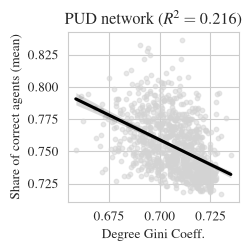

In [26]:
plot_linear_regression(
    df_pud, 
    x="degree_gini_coefficient", 
    y="mean_share_of_correct_agents_at_convergence", 
    title="PUD network",
    filename="pud_regression_plot"
)

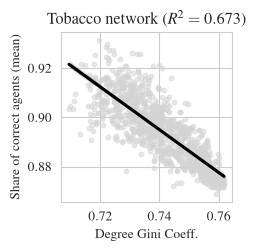

In [27]:
plot_linear_regression(
    df_tobacco,
    title="Tobacco network",
    filename="tobacco_regression_plot"
)

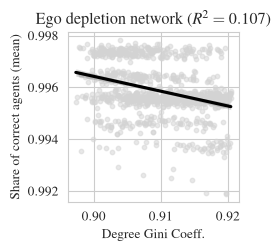

In [28]:
plot_linear_regression(
    df_ego,
    title="Ego depletion network",
    filename="ego_regression_plot"
)

## Option 2: harder problems

### Load csv and create dataframes

⚠️ Note: `uncertainty` is held **fixed** at `0.0001` in this option, so it is not a predictor here — unlike Option 3, which draws it per setting. A constant column would contribute nothing to the fit and make `n_experiments` look collinear with the intercept.

The csv is produced by `2d. GColab Simulations Equality - Aggregation.ipynb`; copy it into `results/` before running this section.

In [ ]:
df_summary = load_summary("option2_harder")
df_pud = df_summary[df_summary["network"] == "pud"]
df_tobacco = df_summary[df_summary["network"] == "tobacco"]
df_ego = df_summary[df_summary["network"] == "ego"]
predictors = [
    "degree_gini_coefficient", 
    "approx_average_clustering_coefficient",
] # "uncertainty", "n_experiments"

In [ ]:
# Option 2 is the long one, and its arms do not necessarily finish together —
# the Ego arm in particular has lagged. Read the per-network counts before the
# regressions rather than after: an arm still filling in gives a perfectly
# well-formed fit on fewer variants, and nothing downstream would say so.
print(df_summary["network"].value_counts(), "\n")

uncertainty_values = df_summary["uncertainty"].unique()
print(f"Problem Easiness: {uncertainty_values} (fixed by design in this option)")
print(df_summary["n_experiments"].value_counts())

### Linear regressions: Short summaries

In [ ]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=False,
)
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=False,
)
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=False,
)

### Linear regressions: Full overview

In [ ]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=True,
)

### Combined LaTeX table (PUD / Tobacco / Ego)

In [ ]:
combined_stats = {}
for df in [df_pud, df_tobacco, df_ego]:
    reg_stats = linear_regression(
        df,
        predictors=predictors,
        print_results=False,
        return_stats=True,
    )
    combined_stats[reg_stats["column_label"]] = reg_stats

combined_latex = regression_stats_to_latex(
    combined_stats,
    column_labels={"pud": "PUD", "tobacco": "Tobacco", "ego": "Ego depletion"},
)
print(combined_latex)

### Plots

`plot_linear_regression` and `save_figure_in_paper_fig_dir` are the ones defined in the Option 1 section above — not redefined here, so a change to either applies to every option's figures rather than to whichever copy was edited.

`filename` is left commented out, as in Option 3: Option 1 already writes `results/pud_regression_plot.png` and friends, and passing the same names here would silently overwrite those with Option 2's figures. Uncomment the distinct names below to save these.

In [ ]:
plot_linear_regression(
    df_pud, 
    x="degree_gini_coefficient", 
    y="mean_share_of_correct_agents_at_convergence", 
    title="PUD network",
    # filename="pud_regression_plot_option2"
)

In [ ]:
plot_linear_regression(
    df_tobacco,
    title="Tobacco network",
    # filename="tobacco_regression_plot_option2"
)

In [ ]:
plot_linear_regression(
    df_ego,
    title="Ego depletion network",
    # filename="ego_regression_plot_option2"
)

## Option 3: varying problem easiness

### Load csv and create dataframes

⚠️ Note: Depending on the details of the simulation study, you might have to include `uncertainty` and/or `n_experiments` as predictors.

In [29]:
df_summary = load_summary("option3_phase_transition")
df_pud = df_summary[df_summary["network"] == "pud"]
df_tobacco = df_summary[df_summary["network"] == "tobacco"]
df_ego = df_summary[df_summary["network"] == "ego"]
predictors = [
    "degree_gini_coefficient", 
    "approx_average_clustering_coefficient",
 "uncertainty"]

In [44]:
print(df_pud["n_experiments"].value_counts())
uncertainty_values = df_pud["uncertainty"].values
print(f"Problem Easiness.\n\t Min: {min(uncertainty_values):.6f}\n\t Max: {max(uncertainty_values):.6f}")

n_experiments
1000    500
Name: count, dtype: int64
Problem Easiness.
	 Min: 0.000101
	 Max: 0.001000


### Linear regressions: Short summaries

In [31]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=False,
)
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=False,
)
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=False,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.813 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Problem Easiness,0.878939,4.124520,Large,0.0000
Degree Gini Coeff.,-0.189663,0.184480,Medium,0.0000
Clustering Coeff.,0.013594,0.000945,Negligible,0.4939


🔍 TOBACCO — Linear Regression — Short Summary
R² = 0.74 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Problem Easiness,0.762757,2.238959,Large,0.000
Degree Gini Coeff.,-0.399863,0.615184,Large,0.000
Clustering Coeff.,-0.019122,0.001407,Negligible,0.404


🔍 EGO — Linear Regression — Short Summary
R² = 0.643 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Problem Easiness,0.801940,1.798987,Large,0.0000
Degree Gini Coeff.,-0.063399,0.011011,Negligible,0.0198
Clustering Coeff.,-0.003483,0.000033,Negligible,0.8978


### Linear regressions: Full overview

In [32]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=True,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.813 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Problem Easiness,0.878939,4.124520,Large,0.0000
Degree Gini Coeff.,-0.189663,0.184480,Medium,0.0000
Clustering Coeff.,0.013594,0.000945,Negligible,0.4939


------------------------------------------------------------
Descriptive Statistics
------------------------------------------------------------
- The length of the data is: 500


,Mean,Std,Min,Max
degree_gini_coefficient,0.707437,0.013295,0.658750,0.729167
approx_average_clustering_coefficient,0.165722,0.005019,0.138073,0.181449
uncertainty,0.000550,0.000263,0.000101,0.001000


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


...

,Mean,Std,Min,Max
degree_gini_coefficient,0.909718,0.005960,0.897349,0.920455
approx_average_clustering_coefficient,0.592206,0.003199,0.573826,0.600235
uncertainty,0.000546,0.000262,0.000102,0.000995


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


,,correlation,interpretation
variable 1,variable 2,,
Degree Gini Coeff.,Clustering Coeff.,0.143996,weak


,VIF,VIF interpretation
variable,,
Degree Gini Coeff.,1.021174,minimal multicollinearity
Clustering Coeff.,1.021174,minimal multicollinearity


------------------------------------------------------------
Full Summary
------------------------------------------------------------
                                  OLS Regression Results                                  
Dep. Variable:     Share of correct agents (mean)   R-squared:                       0.643
Model:                                        OLS   Adj. R-squared:                  0.641
Method:                             Least Squares   F-statistic:                     297.9
Date:                            Wed, 26 Aug 2026   Prob (F-statistic):          1.55e-110
Time:                                    10:51:32   Log-Likelihood:                 1550.2
No. Observations:                             500   AIC:                            -3092.
Df Residuals:                                 496   BIC:                            -3076.
Df Model:                                       3                                         
Covariance Type:                        nonrob

### Plots

In [33]:
def save_figure_in_paper_fig_dir(
    filename, *args, **kwargs
):
    """
    Saves a figure in the paper_fig_dir directory.

    Skips instead of raising when PAPER_FIG_DIR is unset or missing: it comes
    from a .env that exists on the laptop where the paper is written and not on
    a Colab runtime, and a figure that has already been written to FIGURE_DIR
    should not be turned into an exception by the copy to a second location.
    """
    if paper_fig_dir is None:
        print("  (PAPER_FIG_DIR unset — not copying to the paper directory)")
        return
    if not os.path.exists(Path(paper_fig_dir).expanduser()):
        print(f"  (PAPER_FIG_DIR '{paper_fig_dir}' does not exist — not copying)")
        return
    fig_path = Path(paper_fig_dir).expanduser() / filename
    plt.savefig(fig_path, *args, **kwargs)

In [34]:
def plot_linear_regression(
        df: pd.DataFrame,
        x: str = "degree_gini_coefficient",
        y: str = "mean_share_of_correct_agents_at_convergence",
        title: str = "Linear Regression",
        filename: str | None = None,
        show_plot: bool = True,
):
    sns.set_style("whitegrid")

    plt.rcParams.update(
        {
            "text.usetex": USETEX,  # set in the environment cell; False on a TeX-less runtime
            "text.latex.preamble": r"\usepackage{mathptmx}",
            "font.family": "serif",
            "font.size": 9.75,
        }
    )
    plt.figure(figsize=(2.2, 2.2))
    
    fig = sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter=True,
        scatter_kws={"s": 10, "alpha": 0.5, "color":"lightgray"},
        line_kws={"color": "black"},
    )
    
    x_label = rename_dict.get(x, x)
    y_label = rename_dict.get(y, y)
    fig.set_xlabel(x_label)
    fig.set_ylabel(y_label)

    x_values = df["degree_gini_coefficient"].values
    y_values = df["mean_share_of_correct_agents_at_convergence"].values

    slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, y_values)
    fig.set_title(f"{title} ($R^2={r_value**2:.3f}$)")
    if filename:
        plt.savefig(
            FIGURE_DIR / f"{filename}.png",  # Drive on Colab; the clone does not survive
            bbox_inches="tight",
            dpi=800,
            format="png",
        )
        save_figure_in_paper_fig_dir(
            f"{filename}.png",
            bbox_inches="tight",
            dpi=800,
            format="png",
        )

    if show_plot:
        plt.show()


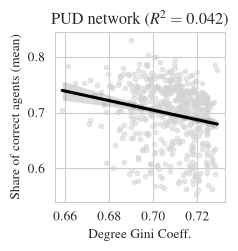

In [35]:
plot_linear_regression(
    df_pud, 
    x="degree_gini_coefficient", 
    y="mean_share_of_correct_agents_at_convergence", 
    title="PUD network",
    # filename="pud_regression_plot"
)

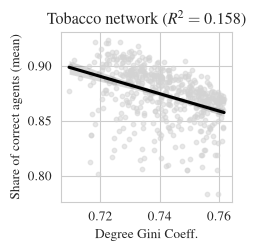

In [36]:
plot_linear_regression(
    df_tobacco,
    title="Tobacco network",
    # filename="tobacco_regression_plot"
)

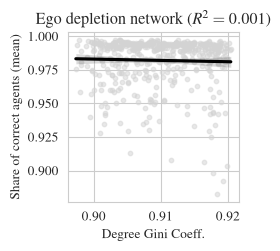

In [37]:
plot_linear_regression(
    df_ego,
    title="Ego depletion network",
    # filename="ego_regression_plot"
)